# Cluster operations

This tutorial shows how to use `imf` to sample populations of stars from its IMF models and demonstrates how to use it to assist in visualizing those populations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Sampling

The ability to sample from the IMF is a core utility for IMF models.
`imf` accomplishes this through the function `make_cluster`. `make_cluster` is part of the `imf` module, but can be directly imported from the top level of `imf` as well. To go over how to use it, we'll show its output for the standard [Kroupa](https://doi.org/10.1046/j.1365-8711.2001.04022.x) and [Chabrier](https://doi.org/10.1086/376392) IMFs.

In [2]:
import imf
from imf import make_cluster

In [3]:
mmin = 0.03
mmax = 120
plot_masses = np.geomspace(0.03,120,100)

In [4]:
chabrier = imf.chabrier
chabrier.mmin = mmin
chabrier.mmax = mmax

We've loaded in the Chabrier IMF here, but it is also possible to sample some common IMF forms by name, which will use the default parameters for each form (see the API for more details). We'll do that with `'kroupa'`.

With that, we can sample by providing `make_cluster` with the desired total mass (say $10^4 \, M_\odot$) and the mass function to sample.

In [5]:
cluster1 = make_cluster(1e4, massfunc='kroupa')
cluster2 = make_cluster(1e4, massfunc=chabrier)

Total cluster mass is 10010 (limit was 10000)
Total cluster mass is 9999.89 (limit was 10000)


Visualizing these clusters, we see that they indeed match up with their companion mass functions. (note: because of a quirk of binning in log space, we compare the clusters against the mass-weighted IMF forms).

Text(0, 0.5, 'N')

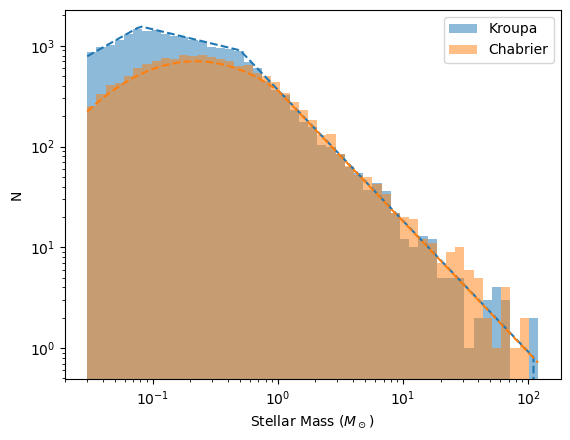

In [6]:
plt.hist(cluster1, bins=np.geomspace(0.03, 120), 
         label='Kroupa', alpha=0.5)
plt.plot(plot_masses, imf.kroupa.mass_weighted(plot_masses) * 4e3,
         '--', color='tab:blue') 
plt.hist(cluster2, bins=np.geomspace(0.03, 120),
         label='Chabrier', alpha=0.5)
plt.plot(plot_masses, chabrier.mass_weighted(plot_masses) * 2.3e3, 
         '--', color='tab:orange') 
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='best')
plt.xlabel(r'Stellar Mass ($M_\odot$)')
plt.ylabel('N')

That's how to sample! However, `make_cluster` has a few more tricks. What
we just saw was random sampling from the IMF. `imf` has a number of different algorithms for random sampling, since doing so is nontrivial (see [Krumholz et al. 2015](https://doi.org/10.1093/mnras/stv1374)). These can be invoked by changing the input to the `stop_criterion` keyword. `make_cluster` supports:
* `'nearest'`: get as close to the total mass as possible given the last few stars *(default)*
* `'before'`: stop just before using all the mass
* `'after'`: stop just after using all the mass
* `'sorted'`: get as close to the total mass as possible given the most massive stars produced.


In [7]:
clst = make_cluster(1e3, massfunc='kroupa')
clst = make_cluster(1e3, massfunc='kroupa', stop_criterion='before')
clst = make_cluster(1e3, massfunc='kroupa', stop_criterion='after')
clst = make_cluster(1e3, massfunc='kroupa', stop_criterion='sorted')

Total cluster mass is 999.918 (limit was 1000)
Total cluster mass is 997.757 (limit was 1000)
Total cluster mass is 1000.19 (limit was 1000)
Total cluster mass is 1012.07 (limit was 1000)


Additionally, we can *optimally* sample a population, i.e. produce a 
population which perfectly reproduces the IMF with a given mass budget. We can do this by providing the `sampling` keyword with `'optimal'`, instead of the default `'random'`. We'll move down to $10^3 \, M_\odot$ here, both to demonstrate optimal sampling in a mass regime where sampling stochasticity tends to be a little more noticeable and for a future purpose.

In [8]:
cluster1 = make_cluster(1e3, massfunc='kroupa', sampling='optimal')
cluster2 = make_cluster(1e3, massfunc=chabrier, sampling='optimal')

/blue/adamginsburg/richardson.t/dev/imf/imf/imf.py:926: RuntimeWarning: divide by zero encountered in log
  if not np.logical_or(np.isfinite(np.log(mmin)), np.isfinite(np.log(tolerance))):


Total cluster mass is 999.973 (limit was 1000)
Total cluster mass is 999.972 (limit was 1000)


If we plot them, we can see that these clusters follow the shape of 
the IMF down to the lower limit on stellar mass.

Text(0, 0.5, 'N')

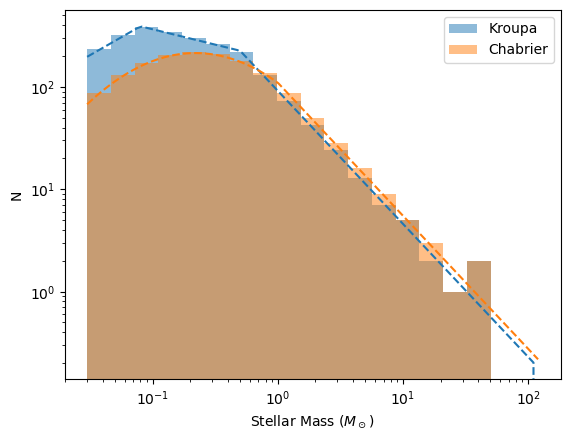

In [9]:
plt.hist(cluster1, bins=np.geomspace(0.03,120,20), 
         label='Kroupa', alpha=0.5)
plt.plot(plot_masses, imf.kroupa.mass_weighted(plot_masses) * 1e3,
         '--', color='tab:blue') 
plt.hist(cluster2, bins=np.geomspace(0.03,120,20),
         label='Chabrier', alpha=0.5)
plt.plot(plot_masses, chabrier.mass_weighted(plot_masses) * 7e2, 
         '--', color='tab:orange') 
plt.xscale('log')
plt.yscale('log')
plt.legend(loc='best')
plt.xlabel(r'Stellar Mass ($M_\odot$)')
plt.ylabel('N')

There's also much less stochasticity from bin to bin, as expected.
While there appear to be some deviations, if we're a little more careful about how we bin the cluster members by properly tracking $dn$ and $dm$/$d \, {\rm log} \, m$:

In [10]:
def hist_props(stars,mmin,n_members=10):
    edges = [stars[0] * 1.01]
    for i in range(1,np.floor_divide(len(stars),n_members)):
        try:
            edge = (stars[n_members*i-1] + stars[n_members*i]) / 2
            edges.append(edge)
        except(IndexError):
            continue
    edges.append(mmin)
    edges = np.array(edges)[::-1]

    dm = np.log10(edges[1:]) - np.log10(edges[:-1])

    weights = np.ones(len(stars))
    for i in range(len(dm)):
        weights[np.logical_and(stars > edges[i],stars < edges[i+1])] *= 1/dm[i]
        
    return edges,weights

Text(0, 0.5, 'N')

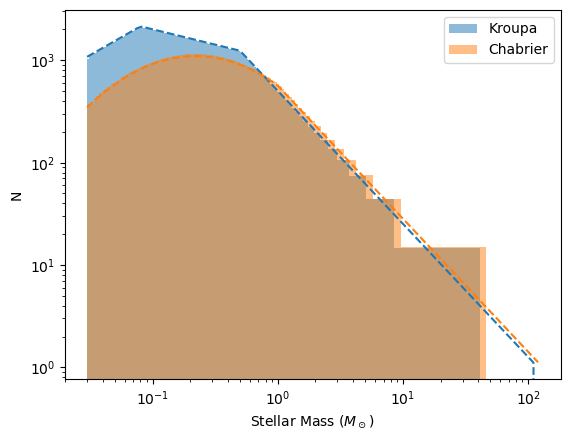

In [11]:
edges, weights = hist_props(cluster1,mmin)
plt.hist(cluster1, bins=edges, weights=weights, 
         label='Kroupa', alpha=0.5)
plt.plot(plot_masses, imf.kroupa.mass_weighted(plot_masses) * 5.5e3,
         '--', color='tab:blue') 

edges, weights = hist_props(cluster2,mmin)
plt.hist(cluster2, bins=edges, weights=weights,
         label='Chabrier', alpha=0.5)
plt.plot(plot_masses, chabrier.mass_weighted(plot_masses) * 3.6e3, 
         '--', color='tab:orange') 

plt.xscale('log')
plt.yscale('log')
plt.legend(loc='best')
plt.xlabel(r'Stellar Mass ($M_\odot$)')
plt.ylabel('N')

We see that optimal sampling does in fact perfectly reproduce the base
IMF.

## Visualizing

Now that we've made clusters, we are not limited to showing them as 
histograms; we can also show the individual members! `imf`'s `visualization` module contains some helpful functions for those looking to represent sampled populations. The primary interface here is the function `plotinfo`, which returns the $x$ and $y$ positions of clusters following a provided IMF and associated colors assigned by mass.

In [12]:
from imf.visualization import plotinfo

`plotinfo` can be invoked either with a total cluster mass `mtot` or a
pregenerated set of `masses`, in addition to the parent mass function. If a cluster does not exist at time of calling, `plotinfo` will make one using `make_cluster`; any arguments for that can also be passed to `plotinfo` to steer the sampling. Here, we'll get the info for the two mass functions we've been tracking:

In [13]:
k_info = plotinfo(mtot=1e3, massfunc='kroupa', mmin=mmin, mmax=mmax)
c_info = plotinfo(masses=cluster2, massfunc=chabrier)

Total cluster mass is 999.136 (limit was 1000)


Once the info is returned, it can be fed directly into standard python
plotting software. By default, the $y$ positions are given in log space, but the real values can be accessed by changing the `log` keyword to `False`.

Text(0, 0.5, 'dn/dm')

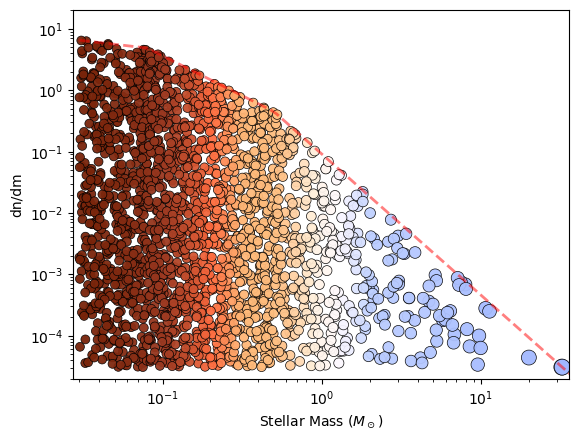

In [14]:
xpos, ypos, colors = k_info

plt.figure()
plt.scatter(xpos, 10**ypos, c=colors, s=np.log10(xpos+3)*85,
            linewidths=0.5, edgecolors=(0, 0, 0, 0.25), alpha=0.95)
plt.plot(plot_masses, imf.kroupa(plot_masses), 'r--', linewidth=2, alpha=0.5)

plt.xscale('log')
plt.yscale('log')
plt.xlim(min(xpos)/1.1, max(xpos)*1.1)
plt.ylim(10**(min(ypos)-0.2),10**(max(ypos)+0.5))
plt.xlabel(r'Stellar Mass ($M_\odot$)')
plt.ylabel('dn/dm')

Text(0, 0.5, 'dn/dm')

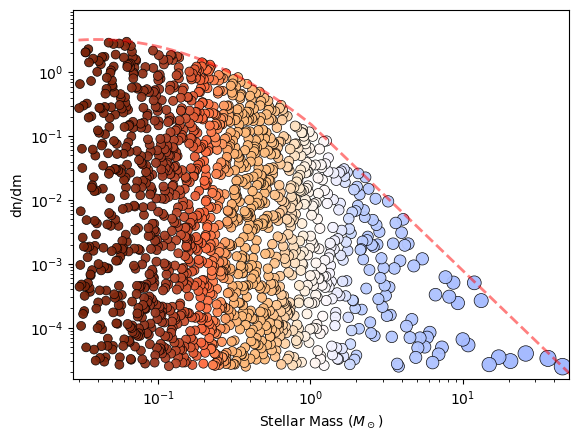

In [15]:
xpos, ypos, colors = c_info

plt.figure()
plt.scatter(xpos, 10**np.array(ypos), c=colors, s=np.log10(xpos+3)*85,
            linewidths=0.5, edgecolors=(0, 0, 0, 0.25), alpha=0.95)
plt.plot(plot_masses, chabrier(plot_masses), 'r--', linewidth=2, alpha=0.5)

plt.xscale('log')
plt.yscale('log')
plt.xlim(min(xpos)/1.1, max(xpos)*1.1)
plt.ylim(10**(min(ypos)-0.2),10**(max(ypos)+0.5))
plt.xlabel(r'Stellar Mass ($M_\odot$)')
plt.ylabel('dn/dm')

By using a less massive cluster, it's easier to see how the Kroupa
population has comparatively more low-mass members than the Chabrier population and vice versa with high mass. `imf` also has some functionality related to coloration; see the API for more details.